# Figure 4: Reward Rate vs. Bound

Translation of `Figure04_RRvsBound.m`

## What this notebook does

Shows how participants' decision bounds relate to their reward rate across three blocks in the online (OL) task, and how bounds adapt during the first 40 trials of each block.

**Formatted figure (2 rows × 3 columns)**:
- **Top row** (one panel per block): Scatter of mean bound (x) vs. reward rate (y) per subject, with a simulation ribbon (5th–95th percentile from 100 simulated subjects). Dashed crosshair lines mark the optimal bound (blue, peak of ideal RR curve) and the participant median (orange).
- **Bottom row** (one panel per block): Within-block z-scored bound adaptation curve (mean ± SEM ribbon) with permutation null band, plus a small τ inset in the upper-right corner.

**Bound comparison across blocks** (standalone, not in final figure): scatter of mean bound in block 1 vs. block 2 and block 2 vs. block 3.

**Data**: OL task, all three blocks, lowest SNR condition (SNR index 0).

## Imports

Imports standard scientific Python libraries and pigeon analysis functions. No data loading or filtering.

## Load data

Loads all OL (online) trials via `get_data_table(task_type='OL')`. This reads all subject CSV files, computes bounds and DTs, marks wall hits, and applies bias correction if available.

## Compute bound and coin summaries

**`get_bound_summary`** (via `get_good_trial_array` internally):
- **Data included**: `DT ≥ 2`, `trial_number ≥ 10`, `bound` finite and non-zero, `correct ≥ 0`, `wall_hit = False`, `rt_below_cutoff = False`
- **Data excluded**: Short DT trials, warm-up trials, wall-hit trials, missing bounds
- Output: mean and std of |bound| per (subject, block, SNR) using `max_rt='all'` (no per-DT binning)

**Coin summary** (computed inline):
- For each (subject, block, SNR), takes the last `coin_count` value (cumulative total at end of block)
- Reward rate = total coins / 600 steps per block
- **Data included**: All trials sorted by trial number; last coin_count value per group
- **Data excluded**: Subjects/blocks/SNRs with no valid trials

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt
import scipy.stats

from pigeon.data import get_data_table
from pigeon.stats import get_bound_summary
from pigeon.simulate import get_simulated_data_table
from pigeon.pathDefaults import FIGURES_DIR

In [2]:
data_table_ol = get_data_table(task_type='OL')

  1: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pigeon/Data/Pigeon_OL/prolificcsvs/PigeonTask_2022-11-21_14h39.24.096.csv
  2: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pigeon/Data/Pigeon_OL/prolificcsvs/PigeonTask_2022-11-21_15h37.48.260.csv
  3: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pigeon/Data/Pigeon_OL/prolificcsvs/PigeonTask_2022-11-21_16h34.46.761.csv
  4: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pigeon/Data/Pigeon_OL/prolificcsvs/PigeonTask_2022-11-21_16h35.25.285.csv
  5: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pigeon/Data/Pigeon_OL/prolificcsvs/PigeonTask_2022-11-21_16h36.33.669.csv
  6: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pigeon/Data/Pigeon_OL/prolificcsvs/PigeonTask_2022-11-21_16h36.41.364.csv
  7: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pigeon/Data/Pigeon_OL/prolificcsvs/PigeonTask_2022-11-21_16h36.49.086.csv
  8: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pi

In [3]:
BLOCKS    = [1, 2, 3]
SNR_INDEX = 0  # first (lowest) SNR level

subjects   = np.sort(data_table_ol['subject_index'].dropna().unique())
n_subjects = len(subjects)

# bound_summary shape: (n_subjects, n_blocks, n_snrs, 1, 3)
# max_rt='all' collapses over all DT bins -> single aggregate entry per subject/block/SNR
# last dim: [mean_abs_bound, std_abs_bound, n_trials]
bound_summary = get_bound_summary(data_table_ol, blocks=BLOCKS, max_rt='all')
print('bound_summary shape:', bound_summary.shape)

# Compute coin_summary: total coins per subject × block × SNR
# coin_count is a cumulative running total, so we take the last value (sorted by trial_number)
# Dividing by 600 (steps_per_block) gives reward rate
abs_snr  = np.abs(data_table_ol['snr'].to_numpy())
snr_vals = np.sort(np.unique(abs_snr[np.isfinite(abs_snr)]))
n_snrs   = len(snr_vals)

# Simulation constants for the RR ribbon in the formatted figure
GENERATIVE_STD  = 0.15                                         # per-step noise SD (matches real OL task)
GENERATIVE_MEAN = float(snr_vals[SNR_INDEX]) * GENERATIVE_STD  # drift for SNR_INDEX
SIM_BOUNDS      = np.arange(0.01, 0.71, 0.02)                 # bound sweep for RR ribbon
NUM_SIM_SUBJ    = 100                                          # simulated subjects per bound value
print(f'SNR levels: {np.round(snr_vals, 3)},  GENERATIVE_MEAN={GENERATIVE_MEAN:.4f} '
      f'(SNR={GENERATIVE_MEAN/GENERATIVE_STD:.3f})')

# Sort once up front so the inner loop just slices, no per-iteration sort
_dt_sorted      = data_table_ol.sort_values('trial_number')
_abs_snr_sorted = np.abs(_dt_sorted['snr'].to_numpy())

coin_summary = np.full((n_subjects, len(BLOCKS), n_snrs), np.nan)

for si, subj in enumerate(subjects):
    for bi, block in enumerate(BLOCKS):
        for ni, snr_val in enumerate(snr_vals):
            ls = (
                (_dt_sorted['subject_index'] == subj) &
                (_dt_sorted['block_index']   == block) &
                np.isclose(_abs_snr_sorted, snr_val)
            )
            if ls.any():
                vals = _dt_sorted.loc[ls, 'coin_count'].dropna()
                if len(vals) > 0:
                    coin_summary[si, bi, ni] = vals.iloc[-1]

print('coin_summary shape:', coin_summary.shape)

bound_summary shape: (60, 3, 2, 1, 3)
SNR levels: [0.333 1.   ],  GENERATIVE_MEAN=0.0500 (SNR=0.333)
coin_summary shape: (60, 3, 2)


## Bound summary statistics per block

For each block, reports the median [IQR] of the **mean bound** across participants (SNR index 0). Only subjects with a finite mean bound are included.

In [4]:
for bi, block in enumerate(BLOCKS):
    vals = bound_summary[:, bi, SNR_INDEX, 0, 0]
    vals = vals[np.isfinite(vals)]
    q25, med, q75 = np.percentile(vals, [25, 50, 75])
    print(f'Block {block}: {med:.3f} [{q25:.3f}, {q75:.3f}]')

Block 1: 0.216 [0.165, 0.271]
Block 2: 0.314 [0.239, 0.386]
Block 3: 0.282 [0.229, 0.337]


## Spearman correlation: mean bound vs. reward rate, per block

For each block, reports the Spearman ρ and associated p-value between each participant's mean bound and their reward rate (total coins / 600 steps). Only subjects with finite values for both measures are included.

In [5]:
for bi, block in enumerate(BLOCKS):
    mean_bound  = bound_summary[:, bi, SNR_INDEX, 0, 0]
    reward_rate = coin_summary[:, bi, SNR_INDEX] / 600
    valid = np.isfinite(mean_bound) & np.isfinite(reward_rate)
    r, p = scipy.stats.spearmanr(mean_bound[valid], reward_rate[valid])
    print(f'Block {block}: Spearman r={r:.3f}, p={p:.3f}')

Block 1: Spearman r=-0.766, p=0.000
Block 2: Spearman r=0.786, p=0.000
Block 3: Spearman r=0.125, p=0.358


## Bound comparison across blocks

Scatter of mean bound block 1 vs. block 2 (left) and block 2 vs. block 3 (right). One point per subject. Not part of the final figure.

Block 1 vs 2: median diff=0.08 [0.05 0.15], p=0.00, Spearman r=0.59 (p=0.000)
   RR: Spearman r=-0.44 (p=0.000)
Block 2 vs 3: median diff=-0.02 [-0.08 0.04], p=0.05, Spearman r=0.54 (p=0.000)
   RR: Spearman r=0.08 (p=0.563)


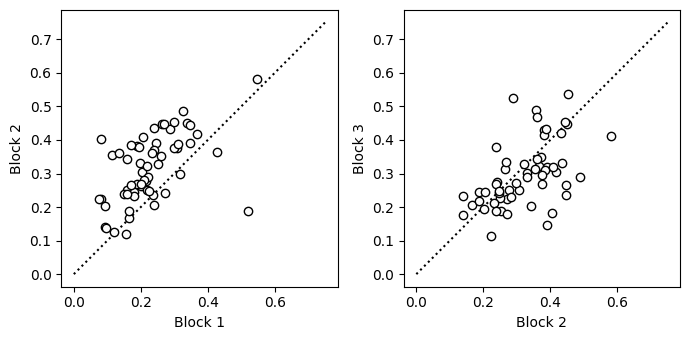

In [6]:
wt = (0.99, 0.99, 0.99)  # near-white marker fill

comparisons = [(0, 1, 1, 2), (1, 2, 2, 3)]  # (bi_x, bi_y, label_x, label_y)

fig, axs = plt.subplots(1, 2, figsize=(7, 3.5))

for ax, (bx, by, lx, ly) in zip(axs, comparisons):
    xs = bound_summary[:, bx, SNR_INDEX, 0, 0]  # mean bound, block lx
    ys = bound_summary[:, by, SNR_INDEX, 0, 0]  # mean bound, block ly

    valid = np.isfinite(xs) & np.isfinite(ys)

    # Identity line
    ax.plot([0, 0.75], [0, 0.75], 'k:')

    # One point per subject
    ax.plot(xs[valid], ys[valid], 'ko', markerfacecolor=wt)

    ax.set_xlabel(f'Block {lx}')
    ax.set_ylabel(f'Block {ly}')

    # Stats: median diff with IQR, Wilcoxon signed-rank, Spearman correlation
    diff = ys[valid] - xs[valid]
    pcts = np.percentile(diff, [25, 50, 75])
    _, p_rank = scipy.stats.wilcoxon(xs[valid], ys[valid])
    r, p_corr = scipy.stats.spearmanr(xs[valid], ys[valid])
    print(f'Block {lx} vs {ly}: median diff={pcts[1]:.2f} [{pcts[0]:.2f} {pcts[2]:.2f}], '
          f'p={p_rank:.2f}, Spearman r={r:.2f} (p={p_corr:.3f})')

    # RR correlation
    xrs = coin_summary[:, bx, SNR_INDEX][valid] / 600
    yrs = coin_summary[:, by, SNR_INDEX][valid] / 600
    rr, pr = scipy.stats.spearmanr(xrs, yrs)
    print(f'   RR: Spearman r={rr:.2f} (p={pr:.3f})')

plt.tight_layout()
plt.show()

## Within-block bound adaptation: methods

For each subject × block, the code below computes a smoothed z-scored `abs_bound`
curve over the first 40 trials and tests whether it shows reliable time-locked
structure relative to a permutation null.  The resulting curves and τ fits are
shown as the bottom row of the formatted figure.

**Smoothed z-scored curve.** `abs_bound` is z-scored per subject × block (so the
curve reflects within-block adaptation relative to that subject's own block-average
bound), then smoothed with a ±3-trial sliding window.  We also compute 1000
permutations of each subject's own trial order within the block — preserving that
subject's noise level but destroying any time structure — giving a null distribution
specific to each subject.  The max-stat (Tmax, 95th percentile over all 40 trials)
of the group-mean null curves provides a multiple-comparison-corrected threshold.

**τ-fit eligibility.** Block 1 is gated by a within-block permutation test
(no preceding block).  Blocks 2 and 3 are gated by a per-subject Mann-Whitney U
test on steady-state |bound| between block[i−1] and block[i] — a subject can shift
reliably between blocks without that shift resolving as a clean within-block
exponential settle, so these criteria are kept separate.  Fits that hit the `tau_max`
boundary are excluded from the τ summary (shown as open triangles in the figure)
since they represent a lower bound, not a measurement.

In [7]:
from scipy.optimize import curve_fit
from pigeon.data import get_good_trial_array

SUPP_MAX_TRIAL = 40
SUPP_BLOCKS    = [1, 2, 3]
SUPP_HALF_WIN  = 3
SUPP_MIN_WIN   = 3
N_PERM         = 1000
PERM_SEED      = 123
SIG_ALPHA      = 0.05
TAU_MAX        = float(SUPP_MAX_TRIAL)  # can't resolve a tau longer than the fit window itself
BETWEEN_MIN_TRIALS = 5  # min good trials per block required to run the between-block test


def _build_window_matrix(t_vals, trial_nums, half_win, min_win):
    """
    Precompute the trial-window averaging weights for one subject x block.
    These weights only depend on which raw trial numbers exist (t_vals), not on the
    bound values themselves, so the same matrix can be reused for the real curve and
    for every permutation of that subject's z values.
    """
    n_bins = len(trial_nums)
    W = np.zeros((n_bins, len(t_vals)))
    valid = np.zeros(n_bins, dtype=bool)
    for ti, t in enumerate(trial_nums):
        mask = (t_vals >= t - half_win) & (t_vals <= t + half_win)
        cnt = mask.sum()
        if cnt >= min_win:
            W[ti, mask] = 1.0 / cnt
            valid[ti] = True
    return W, valid


def _exp_decay(t, A, tau, C):
    return A * np.exp(-t / tau) + C


def fit_exp_tau(trial_nums, z_vals, min_valid=8, tau_max=TAU_MAX):
    """
    Fit A*exp(-t/tau)+C. Returns (tau, censored):
      tau      -- fitted time constant, or NaN on failure / insufficient data
      censored -- True if the fit hit the tau_max boundary, i.e. the optimizer found
                  no resolvable decay within the fit window (slow drift, not a fast
                  settle) -- these tau values describe a lower bound, not a measurement.
    """
    valid = np.isfinite(z_vals)
    if valid.sum() < min_valid:
        return np.nan, False
    t = trial_nums[valid].astype(float)
    y = z_vals[valid]
    A0  = float(y[0] - np.nanmedian(y[-5:]))
    C0  = float(np.nanmedian(y[-5:]))
    try:
        popt, _ = curve_fit(
            _exp_decay, t, y,
            p0=[A0, 10.0, C0],
            bounds=([-np.inf, 0.5, -np.inf], [np.inf, tau_max, np.inf]),
            maxfev=5000,
        )
        tau = float(popt[1])
        return tau, tau >= tau_max - 1e-6
    except Exception:
        return np.nan, False


def compute_per_subject_curves_with_nulls(data_table, max_trial, blocks,
                                           half_win=SUPP_HALF_WIN, min_win=SUPP_MIN_WIN,
                                           n_perm=N_PERM, seed=PERM_SEED):
    """
    For every subject x block, computes the real smoothed z-scored bound curve plus
    a bank of permutation-null curves (trial order shuffled within that subject's own
    block, so each null preserves the subject's own noise level but has no time-locked
    structure). The same null bank is used downstream both for per-subject significance
    testing and for the group-level null band.

    Returns
    -------
    trial_nums  : (max_trial,) int array
    real_curves : (n_subjects, max_trial, n_blocks)
    perm_curves : (n_perm, n_subjects, max_trial, n_blocks)
    subjects    : list of subject indices
    """
    subjects   = sorted(data_table['subject_index'].dropna().unique())
    trial_nums = np.arange(1, max_trial + 1)
    rng = np.random.default_rng(seed)

    real_curves = np.full((len(subjects), max_trial, len(blocks)), np.nan)
    perm_curves = np.full((n_perm, len(subjects), max_trial, len(blocks)), np.nan)

    for bi, block in enumerate(blocks):
        lg = get_good_trial_array(
            data_table, min_dt=1, min_trial_number=None, block_index=block)
        block_data = data_table[lg]

        for si, subj in enumerate(subjects):
            sd = block_data[block_data['subject_index'] == subj]
            if sd['abs_bound'].dropna().shape[0] < 2:
                continue
            mu    = sd['abs_bound'].mean()
            sigma = sd['abs_bound'].std()
            if sigma < 1e-10:
                continue
            z      = (sd['abs_bound'].values - mu) / sigma
            t_vals = sd['trial_number'].values

            W, valid = _build_window_matrix(t_vals, trial_nums, half_win, min_win)

            curve = W @ z
            curve[~valid] = np.nan
            real_curves[si, :, bi] = curve

            z_tiled = np.broadcast_to(z, (n_perm, len(z))).copy()
            z_shuf  = rng.permuted(z_tiled, axis=1)
            perm    = z_shuf @ W.T
            perm[:, ~valid] = np.nan
            perm_curves[:, si, :, bi] = perm

    return trial_nums, real_curves, perm_curves, subjects


def per_subject_significance(real_curves, perm_curves, alpha=SIG_ALPHA):
    """
    Permutation test: does the real smoothed curve deviate from zero more than expected
    by chance? Test statistic = sum of squared curve values across the 40-trial window.
    Returns p-values and a boolean significance mask, shape (n_subjects, n_blocks).
    """
    has_data  = np.any(np.isfinite(real_curves), axis=1)
    obs_stat  = np.nansum(real_curves ** 2, axis=1)
    perm_stat = np.nansum(perm_curves ** 2, axis=2)
    counts    = np.sum(perm_stat >= obs_stat[None, :, :], axis=0)
    pvals     = (1 + counts) / (1 + perm_stat.shape[0])
    pvals     = np.where(has_data, pvals, np.nan)
    sig       = pvals < alpha
    return pvals, sig


def group_null_band(perm_curves, alpha=SIG_ALPHA):
    """
    Max-stat (Tmax) permutation threshold for the group-mean curve: average the null
    curves across subjects within each permutation iteration, take the max absolute
    deviation over all trials in that iteration, then take the alpha-level percentile
    across iterations. This single threshold is corrected for the multiple-comparison
    problem across the 40 trial timepoints.
    Returns threshold per block, shape (n_blocks,).
    """
    group_null = np.nanmean(perm_curves, axis=1)        # (n_perm, max_trial, n_blocks)
    max_stat   = np.nanmax(np.abs(group_null), axis=1)  # (n_perm, n_blocks)
    return np.percentile(max_stat, 100 * (1 - alpha), axis=0)


def between_block_significance(data_table, blocks, alpha=SIG_ALPHA,
                                min_trials=BETWEEN_MIN_TRIALS):
    """
    Per-subject test of whether steady-state |bound| differs between block[i-1] and
    block[i] (i = 1 .. len(blocks)-1). Uses the same default trial-quality filtering as
    get_bound_summary (DT>=2, trial_number>=10, wall_hit and rt_below_cutoff excluded) --
    i.e. this is the same steady-state bound quantity compared in the block-vs-block
    scatter plots earlier in this notebook, but tested per subject with an unpaired,
    two-sided Mann-Whitney U test (no normality assumption) instead of only at the
    group level.

    Returns
    -------
    pvals : (n_subjects, n_blocks) -- column 0 is NaN (no preceding block to compare)
    sig   : (n_subjects, n_blocks) bool -- column 0 is always False
    """
    subjects   = sorted(data_table['subject_index'].dropna().unique())
    n_subjects = len(subjects)
    n_blocks   = len(blocks)
    pvals = np.full((n_subjects, n_blocks), np.nan)
    sig   = np.zeros((n_subjects, n_blocks), dtype=bool)

    lg_by_block = {block: get_good_trial_array(data_table, block_index=block) for block in blocks}

    for bi in range(1, n_blocks):
        lg_prev = lg_by_block[blocks[bi - 1]]
        lg_cur  = lg_by_block[blocks[bi]]

        for si, subj in enumerate(subjects):
            subj_mask = data_table['subject_index'] == subj
            x_prev = data_table.loc[subj_mask & lg_prev, 'abs_bound'].dropna().to_numpy()
            x_cur  = data_table.loc[subj_mask & lg_cur,  'abs_bound'].dropna().to_numpy()
            if len(x_prev) < min_trials or len(x_cur) < min_trials:
                continue
            try:
                _, p = scipy.stats.mannwhitneyu(x_prev, x_cur, alternative='two-sided')
            except ValueError:
                continue
            pvals[si, bi] = p
            sig[si, bi]   = p < alpha

    return pvals, sig

In [8]:
# Load OL data retaining all 6 raw blocks (combine_snr=False) for per-block analysis
data_table_ol_blocks = get_data_table(task_type='OL', combine_snr=False)

supp_trial_nums, supp_real, supp_perm, supp_subjects = compute_per_subject_curves_with_nulls(
    data_table_ol_blocks, SUPP_MAX_TRIAL, SUPP_BLOCKS)

# Group mean ± SEM for ribbon plots (all subjects, for display)
_n_valid       = np.sum(np.isfinite(supp_real), axis=0)
supp_mean      = np.nanmean(supp_real, axis=0)
supp_sem       = np.nanstd(supp_real, axis=0) / np.sqrt(np.maximum(_n_valid, 1))
supp_sem[_n_valid < 2] = np.nan

# Permutation-based group null band (max-stat corrected across the 40 trials) -- this
# and the within-block significance test below still describe the *within-block* curve
# shown in the top row, independent of which criterion gates the tau fits below.
supp_null_thresh = group_null_band(supp_perm)
supp_pvals, supp_sig = per_subject_significance(supp_real, supp_perm)

# Between-block significance: for blocks 2 and 3, does this subject's steady-state
# |bound| reliably differ from the immediately preceding block? (block 1 has no
# preceding block, so this is undefined there -- column 0 is all False/NaN.)
supp_between_pvals, supp_sig_between = between_block_significance(
    data_table_ol_blocks, SUPP_BLOCKS)

# Tau-fit eligibility: block 1 uses the within-block adaptation test (no alternative
# exists); blocks 2 and 3 use the between-block change test instead.
supp_sig_tau = supp_sig.copy()
supp_sig_tau[:, 1:] = supp_sig_between[:, 1:]

# Per-subject exponential fits -- only for subjects classified as eligible above.
# `censored` flags fits that hit tau_max: a real (eligible) deviation that isn't well
# described by a fast exponential settle within the 40-trial window (e.g. slow drift) --
# these are excluded from the tau summary/plot rather than silently padding it at the cap.
supp_taus     = np.full((len(supp_subjects), len(SUPP_BLOCKS)), np.nan)
supp_censored = np.zeros((len(supp_subjects), len(SUPP_BLOCKS)), dtype=bool)
for bi in range(len(SUPP_BLOCKS)):
    for si in range(len(supp_subjects)):
        if supp_sig_tau[si, bi]:
            tau, censored = fit_exp_tau(supp_trial_nums, supp_real[si, :, bi])
            supp_taus[si, bi]     = tau
            supp_censored[si, bi] = censored

print('Per-block adaptation summary:')
for bi, block in enumerate(SUPP_BLOCKS):
    n_total   = np.sum(np.any(np.isfinite(supp_real[:, :, bi]), axis=1))
    n_within  = np.sum(supp_sig[:, bi])
    mean_curve = supp_mean[:, bi]
    max_abs   = np.nanmax(np.abs(mean_curve))
    exceeds   = max_abs > supp_null_thresh[bi]
    print(f'  Block {block}: {n_within}/{n_total} subjects show within-block adaptation '
          f'({100 * n_within / max(n_total, 1):.0f}%)')
    print(f'    group mean curve: max|curve|={max_abs:.3f} vs. null threshold '
          f'±{supp_null_thresh[bi]:.3f} -> {"exceeds null" if exceeds else "within null"}')

    if bi == 0:
        n_qual, crit_label = n_within, 'within-block adaptation (no preceding block)'
    else:
        n_qual = np.sum(supp_sig_between[:, bi])
        crit_label = f'significant change vs. block {SUPP_BLOCKS[bi - 1]} (Mann-Whitney U)'
    print(f'    tau-fit eligibility: {n_qual}/{n_total} subjects qualify ({crit_label})')

    is_censored = supp_censored[:, bi]
    vt = supp_taus[:, bi][np.isfinite(supp_taus[:, bi]) & ~is_censored]
    n_cens = np.sum(is_censored)
    if len(vt):
        q25, med, q75 = np.percentile(vt, [25, 50, 75])
        print(f'    τ (eligible, non-censored): median={med:.1f}  '
              f'IQR=[{q25:.1f}, {q75:.1f}]  n={len(vt)}  '
              f'(+{n_cens} censored at tau_max, excluded)')
    else:
        print(f'    τ: no uncensored fits ({n_cens} eligible subjects censored at tau_max)')

  1: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pigeon/Data/Pigeon_OL/prolificcsvs/PigeonTask_2022-11-21_14h39.24.096.csv
  2: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pigeon/Data/Pigeon_OL/prolificcsvs/PigeonTask_2022-11-21_15h37.48.260.csv
  3: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pigeon/Data/Pigeon_OL/prolificcsvs/PigeonTask_2022-11-21_16h34.46.761.csv
  4: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pigeon/Data/Pigeon_OL/prolificcsvs/PigeonTask_2022-11-21_16h35.25.285.csv
  5: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pigeon/Data/Pigeon_OL/prolificcsvs/PigeonTask_2022-11-21_16h36.33.669.csv
  6: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pigeon/Data/Pigeon_OL/prolificcsvs/PigeonTask_2022-11-21_16h36.41.364.csv
  7: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pigeon/Data/Pigeon_OL/prolificcsvs/PigeonTask_2022-11-21_16h36.49.086.csv
  8: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pi

## Formatted figure

Two-row × three-column figure saved to `Figure04.pdf`.

**Top row** (one panel per block): Scatter of mean bound (x) vs. reward rate (y) per
subject.  Pink ribbon = 5th–95th percentile of simulated reward rate vs. bound (100
subjects); red line = simulated median.  Two sets of dashed crosshair lines project
to both axes:
- **Blue** — peak of the ideal (simulated median) RR curve (optimal bound).
- **Orange** — median bound and median reward rate across participants.

**Bottom row** (one panel per block): Group-mean ± SEM ribbon of the smoothed
z-scored bound curve over the first 40 trials.  Grey band = permutation null
(max-stat corrected, 95%).  Lower-right inset: box/jitter plot of τ
(exponential time constant) for eligible subjects; open triangles = censored fits
(τ pinned at tau_max = 40, excluded from the box).

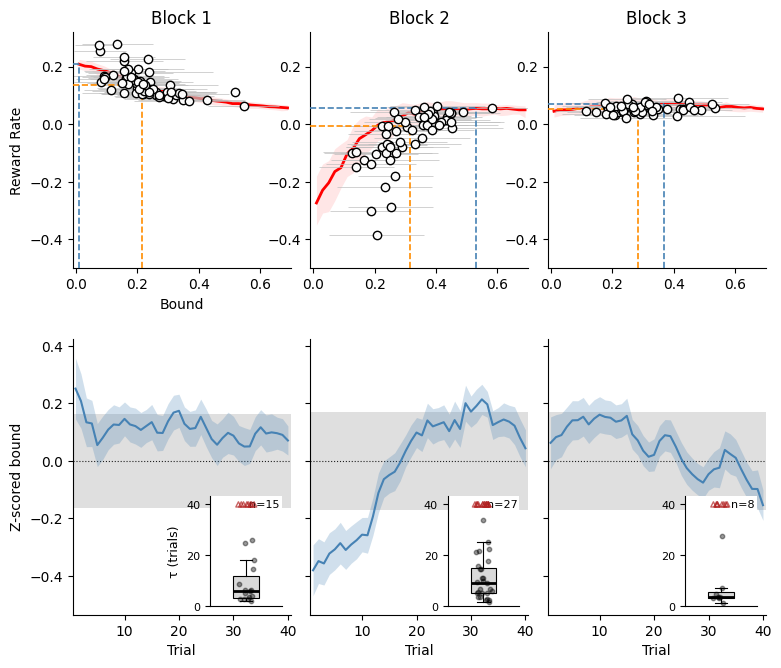

Saved /Users/jigold/Library/CloudStorage/Box-Box/GoldLab/Projects/2025_Pigeon/Figures/Figure04_combined.pdf

τ fits (eligible, non-censored):
  Block 1: median=6.1 [3.5, 11.8]  (n=15 good fits, 8 censored, 23 eligible)
  Block 2: median=9.0 [5.1, 15.2]  (n=27 good fits, 14 censored, 41 eligible)
  Block 3: median=3.7 [3.3, 5.5]  (n=8 good fits, 8 censored, 16 eligible)


In [ ]:
import matplotlib.gridspec as gridspec

CM  = 1 / 2.54
WID = 17.6
HTS = [6.0, 7.0]
PSH = 1.8
PSW = 0.5
FS  = 12

fig_h       = sum(HTS) + PSH
panel_w     = (WID - 2 * PSW) / 3
hspace_frac = PSH / np.mean(HTS)
wspace_frac = PSW / panel_w

fig_comb = plt.figure(figsize=(WID * CM, fig_h * CM))
gs_comb  = gridspec.GridSpec(2, 3, figure=fig_comb,
                              height_ratios=HTS,
                              hspace=hspace_frac, wspace=wspace_frac,
                              left=0, right=1, bottom=0, top=1)
axs_top = [fig_comb.add_subplot(gs_comb[0, c]) for c in range(3)]
axs_bot = [fig_comb.add_subplot(gs_comb[1, c]) for c in range(3)]

plt.rcParams.update({'font.size': FS, 'axes.labelsize': FS, 'axes.titlesize': FS})

gr_c = (0.75, 0.75, 0.75)
wt_c = (0.99, 0.99, 0.99)
rp_c = (1.0,  0.9,  0.9)

OPT_COLOR  = 'steelblue'   # peak of the ideal RR curve
DATA_COLOR = 'darkorange'  # median of the empirical data

# ── Pre-compute simulation ribbons for all blocks (single RNG pass) ───────────
# Done up-front so we can determine axis limits before drawing anything.
rng_comb = np.random.default_rng(0)
sbd_all = []
for bi, block in enumerate(BLOCKS):
    sbd = np.full((len(SIM_BOUNDS), 3), np.nan)
    for ss, bnd in enumerate(SIM_BOUNDS):
        sim_table = get_simulated_data_table(
            specs={'num_subjects': NUM_SIM_SUBJ, 'blocks': block},
            generative_mean=GENERATIVE_MEAN,
            bound_mean=bnd,
            rng=rng_comb,
        )
        sim_coins = sim_table.groupby('subject_index')['coin_count'].last().to_numpy()
        sbd[ss] = np.percentile(sim_coins, [5, 50, 95]) / 600
    sbd_all.append(sbd)

# Axis limits that keep every optimal-RR crosshair in frame
all_opt_idx = [int(np.nanargmax(sbd[:, 1])) for sbd in sbd_all]
all_opt_x   = [float(SIM_BOUNDS[i]) for i in all_opt_idx]
all_opt_y   = [float(sbd_all[bi][all_opt_idx[bi], 1]) for bi in range(3)]
x_left      = min(0.0, min(all_opt_x) - 0.02)   # extend left if any optimal is at/near x=0
y_top       = max(max(all_opt_y) * 1.08, 0.32)
TOP_XLIM    = (x_left, 0.7)
TOP_YLIM    = (-0.5, y_top)

# ── Top row: RR vs. bound ─────────────────────────────────────────────────────
for bi, block in enumerate(BLOCKS):
    ax  = axs_top[bi]
    sbd = sbd_all[bi]

    ax.fill_between(SIM_BOUNDS, sbd[:, 0], sbd[:, 2], color=rp_c, linewidth=0)
    ax.plot(SIM_BOUNDS, sbd[:, 1], '-', color='r', linewidth=2)

    # Blue dashed crosshairs for the optimal bound: project to both axes
    best_x = all_opt_x[bi]
    best_y = all_opt_y[bi]
    ax.plot([best_x, best_x], [TOP_YLIM[0], best_y], '--', color=OPT_COLOR, lw=1.2, zorder=3)
    ax.plot([TOP_XLIM[0], best_x], [best_y, best_y], '--', color=OPT_COLOR, lw=1.2, zorder=3)

    # Data scatter: one point per subject, horizontal error bars = ±1 SD bound
    mean_b   = bound_summary[:, bi, SNR_INDEX, 0, 0]
    std_b    = bound_summary[:, bi, SNR_INDEX, 0, 1]
    rr       = coin_summary[:, bi, SNR_INDEX] / 600
    valid_bi = np.isfinite(mean_b) & np.isfinite(rr)

    ax.errorbar(mean_b[valid_bi], rr[valid_bi],
                xerr=std_b[valid_bi], fmt='none',
                ecolor=gr_c, elinewidth=0.5, capsize=0)
    ax.plot(mean_b[valid_bi], rr[valid_bi], 'ko', markerfacecolor=wt_c, zorder=4)

    # Orange dashed crosshairs for the participant median
    med_x = float(np.nanmedian(mean_b[valid_bi]))
    med_y = float(np.nanmedian(rr[valid_bi]))
    ax.plot([med_x, med_x], [TOP_YLIM[0], med_y], '--', color=DATA_COLOR, lw=1.2, zorder=3)
    ax.plot([TOP_XLIM[0], med_x], [med_y, med_y], '--', color=DATA_COLOR, lw=1.2, zorder=3)

    ax.set_xlim(*TOP_XLIM)
    ax.set_ylim(*TOP_YLIM)
    if x_left < 0:
        ax.set_xticks([0, 0.2, 0.4, 0.6])   # hide the negative-margin tick
    ax.set_title(f'Block {block}')
    if bi == 0:
        ax.set_xlabel('Bound')
        ax.set_ylabel('Reward Rate')
    for sp in ['top', 'right']:
        ax.spines[sp].set_visible(False)

# ── Bottom row: within-block learning curves with τ insets ───────────────────
_NULL_COLOR  = (0.5, 0.5, 0.5)
_CURVE_COLOR = 'steelblue'

_top_lo  = min(np.nanmin(supp_mean - supp_sem), -np.max(supp_null_thresh))
_top_hi  = max(np.nanmax(supp_mean + supp_sem),  np.max(supp_null_thresh))
_top_pad = 0.08 * (_top_hi - _top_lo)
_CURVE_YLIM = (_top_lo - _top_pad, _top_hi + _top_pad)

_rng_jit = np.random.default_rng(42)

for bi, block in enumerate(SUPP_BLOCKS):
    ax = axs_bot[bi]
    mn  = supp_mean[:, bi]
    sem = supp_sem[:, bi]
    ok  = np.isfinite(mn) & np.isfinite(sem)
    thr = supp_null_thresh[bi]

    ax.axhline(0, color='k', linestyle=':', linewidth=0.8, zorder=0)
    ax.axhspan(-thr, thr, color=_NULL_COLOR, alpha=0.25, linewidth=0, zorder=0)
    ax.fill_between(supp_trial_nums[ok], mn[ok] - sem[ok], mn[ok] + sem[ok],
                    alpha=0.25, color=_CURVE_COLOR, linewidth=0)
    ax.plot(supp_trial_nums[ok], mn[ok], '-', color=_CURVE_COLOR, linewidth=1.5)

    ax.set_xlim(0.5, SUPP_MAX_TRIAL + 0.5)
    ax.set_ylim(*_CURVE_YLIM)
    if bi == 0:
        ax.set_ylabel('Z-scored bound')
    else:
        ax.tick_params(axis='y', labelleft=False)
    ax.set_xlabel('Trial')
    for sp in ['top', 'right']:
        ax.spines[sp].set_visible(False)

    # ── τ inset (lower-right corner of the learning-curve panel) ──────────────
    ax_ins = ax.inset_axes([0.63, 0.03, 0.33, 0.40])

    is_cens = supp_censored[:, bi]
    vt      = supp_taus[:, bi][np.isfinite(supp_taus[:, bi]) & ~is_cens]
    n_cens  = int(np.sum(is_cens))
    n_qual  = (int(np.sum(supp_sig[:, bi])) if bi == 0
               else int(np.sum(supp_sig_between[:, bi])))

    if len(vt):
        ax_ins.boxplot(vt, positions=[1], widths=0.35,
                       patch_artist=True,
                       medianprops=dict(color='k', linewidth=2),
                       boxprops=dict(facecolor=(0.85, 0.85, 0.85), linewidth=0.8),
                       whiskerprops=dict(linewidth=0.8),
                       capprops=dict(linewidth=0.8),
                       flierprops=dict(marker='none'))
        jit = _rng_jit.uniform(-0.12, 0.12, len(vt))
        ax_ins.scatter(np.ones(len(vt)) + jit, vt, s=10, color='k', alpha=0.4, zorder=4)
    else:
        ax_ins.text(1, SUPP_MAX_TRIAL / 2, 'no fits', ha='center', va='center',
                    fontsize=FS - 4)

    if n_cens:
        jit_c = _rng_jit.uniform(-0.12, 0.12, n_cens)
        ax_ins.scatter(np.ones(n_cens) + jit_c, np.full(n_cens, SUPP_MAX_TRIAL),
                       marker='^', s=14, facecolor='none', edgecolor='firebrick',
                       alpha=0.7, zorder=5)

    # n label inside the inset (good fits only, excluding censored)
    ax_ins.text(0.97, 0.97, f'n={len(vt)}', transform=ax_ins.transAxes,
                ha='right', va='top', fontsize=FS - 4)

    ax_ins.set_xlim(0.5, 1.5)
    ax_ins.set_ylim(0, SUPP_MAX_TRIAL * 1.08)
    ax_ins.set_xticks([])
    if bi == 0:
        ax_ins.set_ylabel('τ (trials)', fontsize=FS - 3)
    ax_ins.tick_params(labelsize=FS - 4)
    for sp in ['top', 'right']:
        ax_ins.spines[sp].set_visible(False)

out_comb = FIGURES_DIR / 'Figure04.pdf'
fig_comb.savefig(out_comb, dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved {out_comb}')

# ── τ summary for manuscript reporting ───────────────────────────────────────
print('\nτ fits (eligible, non-censored):')
for bi, block in enumerate(SUPP_BLOCKS):
    is_cens = supp_censored[:, bi]
    vt      = supp_taus[:, bi][np.isfinite(supp_taus[:, bi]) & ~is_cens]
    n_cens  = int(np.sum(is_cens))
    n_qual  = (int(np.sum(supp_sig[:, bi])) if bi == 0
               else int(np.sum(supp_sig_between[:, bi])))
    if len(vt) >= 3:
        q25, med, q75 = np.percentile(vt, [25, 50, 75])
        print(f'  Block {block}: median={med:.1f} [{q25:.1f}, {q75:.1f}]  '
              f'(n={len(vt)} good fits, {n_cens} censored, {n_qual} eligible)')
    else:
        print(f'  Block {block}: insufficient fits  '
              f'(n={len(vt)} good, {n_cens} censored, {n_qual} eligible)')